# Machine Vision
## Assignment 7 - Recognition



## Introduction

In this assignment, your goal is to classify apples and pears using shape and color features. The figure below shows examples from both classes. There is a slight color difference between the apples and pears. Therefore, we will use the hue of the fruit as our first feature $x_1$. Depending on the viewpoint, the apples are generally more round compared to pears. To represent the roundness, we will use the eccentricity as our second feature $x_2$. The eccentricity will vary between 0 and 1 (the eccentricity of a circe is zero). The features can be combined into a feature vector $\mathbf{x} = [x_1, x_2]^\top$.


This assignment focuses on the classification so the features and class labels have been precomputed and saved to `class_data.npz` file. Let's first read and visualize the samples.

**Note!** The package *scikit-learn* is needed. If the code below produces an error, install it by running `pip install -U scikit-learn` in the terminal (please do not add installation commands to the notebook).

[[23.05909256  0.50872999]
 [26.22227052  0.32685606]
 [23.50354033  0.5416599 ]
 [27.19005821  0.3446652 ]]
['pear' 'apple' 'pear' 'apple']


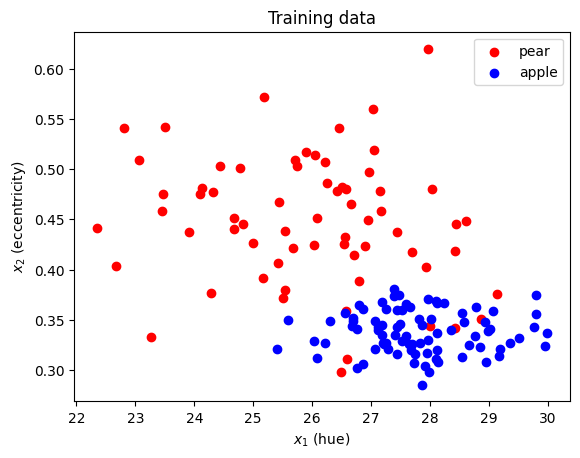

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.neighbors import NearestCentroid

# Load data
data=np.load('class_data.npz')
X_train = data['arr_0'] # Nx2 matrix
y_train = data['arr_1'] # 1xN vector
X_test = data['arr_2']  # Mx2 matrix
y_test = data['arr_3']  # 1xM vector

# Print few feature vectors and
# corresponding true classes
print(X_train[:4,:])
print(y_train[:4])

# Visualize training data
yp = y_train == 'pear'
ya = y_train == 'apple'
X1_train = X_train[yp,:]
X2_train = X_train[ya,:]

fig, ax = plt.subplots()
ax.scatter(X1_train[:,0], X1_train[:,1], c='r', label='pear')
ax.scatter(X2_train[:,0], X2_train[:,1], c='b', label='apple')
ax.set_xlabel('$x_1$ (hue)')
ax.set_ylabel('$x_2$ (eccentricity)')
ax.set_title('Training data')
ax.legend()

## Task 1 - Nearest centroid classifier <span style="color: red;">(0.5 points)</span>

Complete the following code cell to classify the test samples using the __[`nearest centroid classifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestCentroid.html)__.  See the example notebook __[`Recognition.ipynb`](https://github.com/jtheikkila/mvis/blob/master/jupyter/Recognition.ipynb)__ before continuing.

**Instructions**
1. Train the classifier on the training data `X_train` and `y_train` using the `fit()` method. Use **Euclidean distance** as the distance metric.
2. Evaluate the classifier on the independent test data `X_test` and true labels `y_test` using the `score()` method.
3. Print the mean accuracy. Your solution should be correct if the mean accuracy is 0.70.

In [2]:
# ---------- YOUR CODE STARTS HERE -----------

nc = NearestCentroid(metric='euclidean')
nc.fit(X_train,y_train)
nc.score(X_test,y_test)

# ----------- YOUR CODE ENDS HERE ------------

0.7

## Task 2 - Visualization <span style="color: red;">(0.5 points)</span>

Complete the code cell below to visualize the test data (`X_test`, `y_test`). Your plot should:
1. Plot the test samples (`X_test`, `y_test`) using different colors for the classes (as training data was plotted).
2. Show the **class centroids** and the **decision boundary** between the classes.

Refer to the sample code in __[`Recognition.ipynb`](https://github.com/jtheikkila/mvis/blob/master/jupyter/Recognition.ipynb)__ for guidance. It is optional to display true positives (TP), true negatives (TN), false positives (FP) and false negatives (FN) as in the sample code.

**Note:** Euclidean distance does not work well in this case, so the decision boundary will appear as a vertical line.

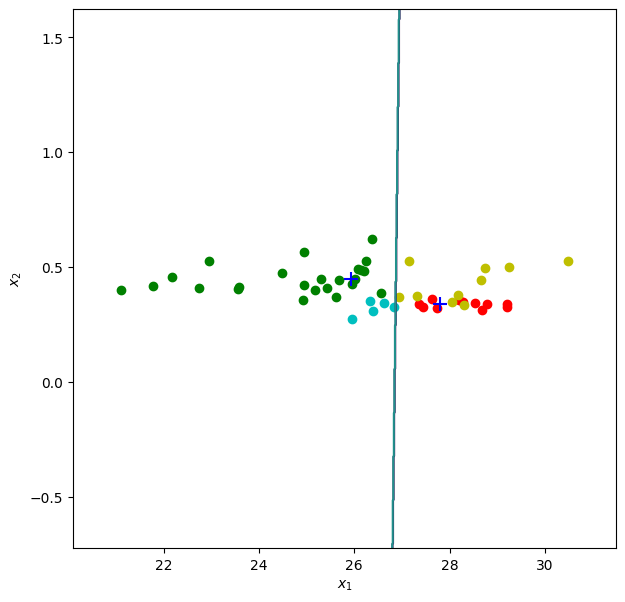

In [3]:
# ---------- YOUR CODE STARTS HERE -----------
y_pred = nc.predict(X_test)

tp = np.logical_and(y_test == 'pear', y_pred == 'pear')
tn = np.logical_and(y_test == 'apple', y_pred == 'apple')
fp = np.logical_and(y_test == 'apple', y_pred == 'pear')
fn = np.logical_and(y_test == 'pear', y_pred == 'apple')

x1 = X_test[:,0]
x2 = X_test[:,1]

x1_min = np.min(x1)-1
x1_max = np.max(x1)+1
x2_min = np.min(x2)-1
x2_max = np.max(x2)+1

x, y = np.meshgrid(np.linspace(x1_min,x1_max,1000),np.linspace(x2_min,x2_max,1000))
grid = np.vstack((x.flatten(), y.flatten())).T
db = nc.predict(grid).reshape(1000,1000)
db = (db == 'pear').astype(np.uint8)

plt.figure(figsize=(7,7))
plt.scatter(X_test[tp,0], X_test[tp,1], c='g')
plt.scatter(X_test[tn,0], X_test[tn,1], c='r')
plt.scatter(X_test[fp,0], X_test[fp,1], c='c')
plt.scatter(X_test[fn,0], X_test[fn,1], c='y')
plt.scatter(nc.centroids_[:,0],nc.centroids_[:,1], c='b', marker='+', s=100)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.contour(x, y, db, 1)
# ----------- YOUR CODE ENDS HERE ------------

## Classification using Mahalanobis distance

Notice that features (eccentricity and hue) are not measured in the same units. A drawback of Euclidean distance is that it assigns equal weight to all dimensions. The clusters that we are trying to model are not spherical so the Euclidean distance does not give an accurate distance. Instead, we can model both clusters as multivariate Gaussian distributions with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$. This implicitly represents the region as an ellipsoid centered at $\boldsymbol{\mu}$ with the axes aligned with the eigenvectors of $\boldsymbol{\Sigma}$. In practice, the parameters $\boldsymbol{\mu}_i$ and $\boldsymbol{\Sigma}_i$ are estimated from the training samples of each class $i$.

Mahalanobis distance is more appropriate here because it scales each dimension according to the observed variance and accounts for covariance between dimensions. The Mahalanobis distance is defined as:

$$
d_M^i = \sqrt{(\mathbf{x}-\boldsymbol{\mu}_i)^\top \boldsymbol{\Sigma}_{i}^{-1} (\mathbf{x}-\boldsymbol{\mu}_i)} \qquad \qquad (1).
$$

In this case, the inverse covariance matrix $\boldsymbol{\Sigma}_{i}^{-1}$ is a $2 \times 2$ matrix because we have two features.

## Task 3 - Mahalanobis distances <span style="color: red;">(1.0 point)</span>

Complete the code cell below by implementing the function `mahalanobisDistances()`. The function should compute the Mahalanobis distance between each test sample in `X` and a class modeled by the training samples `X_train` using Equation 1.

**Instructions**
1. Inside `mahalanobisDistances()`, compute the centroid of `X_train` using __[`np.mean`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.mean.html)__. The centroid is a 2-element vector.
2. Compute the covariance matrix of `X_train` using __[`np.cov`](https://numpy.org/doc/stable/reference/generated/numpy.cov.html)__ The covariance matrix must be a 2 × 2 matrix (see the `rowvar` parameter).
3. Compute the inverse covariance matrix using __[`np.linalg.inv`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html)__.
4. Compute and return the Mahalanobis distances from all test samples `X` to the class defined by `X_train`. The output should be a vector of length M (one distance per test sample).
5. After implementing the function, run the code cell. Your solution is likely correct if the printed mean accuracy is 0.92.

In [4]:
# INPUT
# X       : Feature vectors of the test samples (M x 2 matrix)
# X_train : Training samples of one class (N x 2 matrix)
#
# OUTPUT
# dists   : Mahalanobis distances between the test samples X and the class
#           modeled by X_train (length-M vector)
#
def mahalanobisDistances(X, X_train):

    # ---------- YOUR CODE STARTS HERE -----------

    mean=np.mean(X_train,axis=0)
    cov=np.cov(X_train.T)
    cov_inv=np.linalg.inv(cov)
    difference = X-mean
    dists=np.sqrt(np.einsum('ij,jk,ik->i',difference,cov_inv,difference))


    # ----------- YOUR CODE ENDS HERE ------------

    return dists


# Calculate the distances to each class
D1 = mahalanobisDistances(X_test, X1_train)
D2 = mahalanobisDistances(X_test, X2_train)

# Produce class labels based on the distances
idx = D1 < D2
y_pred = np.array(D1.shape[0] * ['apple'])
y_pred[idx == True] = 'pear'

# Compute mean accuracy
score = np.sum(y_test == y_pred) / y_test.shape[0]
print('Score = %f' % score)


Score = 0.920000


In [ ]:
# LEAVE EMPTY